In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from ipywidgets import interact, interact_manual

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')

# Ubicación del archivo de logs
csv_path = "logs/2026-07-20_18-32-15/system_log.csv"
if not os.path.exists(csv_path):
    csv_path = "robot_ball_log.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Total de registros (ticks): {len(df)}")
else:
    df = None
    print(f"Error: No se encontró el archivo de logs en '{csv_path}'.")
    print("Por favor, ejecuta la simulación en grSim con test_estimation activo antes de correr este notebook.")

Total de registros (ticks): 10374


In [2]:
@interact(
    id=(-1, 3, 1),
    color=(0, 1, 1)
)
def plot_estimation(id=-1, color=0):
    if df is None:
        print("No hay datos para mostrar. Asegúrate de que el archivo de logs exista.")
        return
    
    if id == -1:
        run_data = df[df['RobotID'] == -1]  # Default to RobotID 0 if -1 is selected
    else:
        run_data = df[(df['RobotID'] == id) & (df['Team'] == color)]

    # Crear la figura y los ejes
    fig, axs = plt.subplots(3, 1, figsize=(12, 10))

    # Gráfico de posición estimada vs posición real
    axs[0].plot(run_data['ElapsedTime'], run_data['Pos_X'], label='Posición X', color='blue')
    axs[0].set_title(f'Posición Estimada vs Real (X)')
    axs[0].set_xlabel('ElapsedTime')
    axs[0].set_ylabel('Posición X')
    axs[0].legend()
    axs[0].grid()

    # Estimate speed using backward difference method
    speed = np.zeros(len(run_data))
    speed[1:] = (run_data['Pos_X'].values[1:] - run_data['Pos_X'].values[:-1]) / (run_data['ElapsedTime'].values[1:] - run_data['ElapsedTime'].values[:-1])

    # Gráfico de velocidad
    axs[1].plot(run_data['ElapsedTime'], speed, label='Velocidad', color='green')
    axs[1].set_title(f'Velocidad')
    axs[1].set_xlabel('ElapsedTime')
    axs[1].set_ylabel('Velocidad')
    axs[1].legend()
    axs[1].grid()

    # Gráfico de aceleración
    acceleration = np.zeros(len(run_data))
    acceleration[1:] = (speed[1:] - speed[:-1]) / (run_data['ElapsedTime'].values[1:] - run_data['ElapsedTime'].values[:-1])
    axs[2].plot(run_data['ElapsedTime'], acceleration, label='Aceleración', color='red')
    axs[2].set_title(f'Aceleración')
    axs[2].set_xlabel('ElapsedTime')
    axs[2].set_ylabel('Aceleración')
    axs[2].legend()
    axs[2].grid()

    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=-1, description='id', max=3, min=-1), IntSlider(value=0, description='co…

## EKF

In [3]:
from EKF import ExtendedKalmanFilter as BASELINE

# Estado inicial:
# [x, y, sin(theta), cos(theta), vx, vy, omega]
initial_state = np.array([
    0.0,   # x
    0.0,   # y
    0.0,   # sin(theta)
    1.0,   # cos(theta) -> theta = 0
    0.0,   # vx
    0.0,   # vy
    0.0    # omega
])

# Incertidumbre inicial
initial_cov = np.eye(7) * 0.1

# Ruido del modelo
process_noise = np.diag([
    0.01,  # x
    0.01,  # y
    0.001, # sin(theta)
    0.001, # cos(theta)
    0.1,   # vx
    0.1,   # vy
    0.01   # omega
])

# Ruido de las mediciones (x, y, theta)
measurement_noise = np.diag([
    0.05,
    0.05,
    np.deg2rad(5)**2
])

In [6]:
def plot_filtered_pose(ekf_filter, id=-1, color=0, initial_index=560, window_size=340, 
                       fig=None, plot_base=True, label_suffix="Filtrada", color_base='green', color_filtered='blue'):
    if df is None:
        print("No hay datos para mostrar. Asegúrate de que el archivo de logs exista.")
        return
    
    if id == -1:
        run_data = df[df['RobotID'] == -1]  # Default to robot_id 0 if -1 is selected
    else:
        run_data = df[(df['RobotID'] == id) & (df['team'] == color)]

    x_filtered = run_data['Pos_X'].values.copy()

    for i in range(1, len(run_data)):
        dt = run_data['ElapsedTime'].values[i] - run_data['ElapsedTime'].values[i - 1]
        dt /= 60
        x_meas = run_data['Pos_X'].values[i]
        y_meas = run_data['Pos_Y'].values[i]
        theta_meas = 0.0
        (
            x,
            *_
        ) = ekf_filter.filter_pose(
            x_meas,
            y_meas,
            theta_meas,
            dt,
        )

        x_filtered[i] = x

    # Crear la figura y los ejes
    fig_flag = False
    if fig is None:
        fig, axs = plt.subplots(3, 1, figsize=(12, 10))
    else:
        axs = fig.axes
        fig_flag = True

    cropp = lambda arr, start, window: arr[start:start + window] if window > 0 else arr[start:]

    tick_ax            = cropp(run_data['ElapsedTime'].values, initial_index, window_size)
    x_raw              = cropp(run_data['Pos_X'].values, initial_index, window_size)
    x_filtered_cropped = cropp(x_filtered, initial_index, window_size)

    # Gráfico de posición estimada vs posición real
    if plot_base:
        axs[0].plot(tick_ax, x_raw, label='Posición X', color=color_base)
    axs[0].plot(tick_ax, x_filtered_cropped, label=f'Posición X {label_suffix}', color=color_filtered, alpha=0.7)
    axs[0].set_title(f'Posición Estimada vs Real (X)')
    axs[0].set_xlabel('ElapsedTime')
    axs[0].set_ylabel('Posición X')
    axs[0].legend()
    axs[0].grid()

    # Estimate speed using backward difference method
    speed = np.zeros(len(run_data))
    speed[1:] = (run_data['Pos_X'].values[1:] - run_data['Pos_X'].values[:-1]) / (run_data['ElapsedTime'].values[1:] - run_data['ElapsedTime'].values[:-1])

    speed_filtered = np.zeros(len(run_data))
    speed_filtered[1:] = (x_filtered[1:] - x_filtered[:-1]) / (run_data['ElapsedTime'].values[1:] - run_data['ElapsedTime'].values[:-1])

    sp_cropped     = cropp(speed, initial_index, window_size)
    sp_flt_cropped = cropp(speed_filtered, initial_index, window_size)

    # Gráfico de velocidad
    if plot_base:
        axs[1].plot(tick_ax, sp_cropped, label='Velocidad', color=color_base)
    axs[1].plot(tick_ax, sp_flt_cropped, label=f'Velocidad {label_suffix}', color=color_filtered, alpha=0.7)
    axs[1].set_title(f'Velocidad')
    axs[1].set_xlabel('ElapsedTime')
    axs[1].set_ylabel('Velocidad')
    axs[1].legend()
    axs[1].grid()

    # Gráfico de aceleración
    acceleration = np.zeros(len(run_data))
    acceleration[1:] = (speed[1:] - speed[:-1]) / (run_data['ElapsedTime'].values[1:] - run_data['ElapsedTime'].values[:-1])

    acceleration_filtered = np.zeros(len(run_data))
    acceleration_filtered[1:] = (speed_filtered[1:] - speed_filtered[:-1]) / (run_data['ElapsedTime'].values[1:] - run_data['ElapsedTime'].values[:-1])

    ac_cropped     = cropp(acceleration, initial_index, window_size)
    ac_flt_cropped = cropp(acceleration_filtered, initial_index, window_size)

    if plot_base:
        axs[2].plot(tick_ax, ac_cropped, label='Aceleración', color=color_base)
    axs[2].plot(tick_ax, ac_flt_cropped, label=f'Aceleración {label_suffix}', color=color_filtered, alpha=0.7)
    axs[2].set_title(f'Aceleración')
    axs[2].set_xlabel('ElapsedTime')
    axs[2].set_ylabel('Aceleración')
    axs[2].legend()
    axs[2].grid()

    if fig_flag:
        return fig, axs
    
    plt.tight_layout()
    plt.show()

baseline_params = {
    "P_noise": 0,
    "V_noise": 0,
    "Meas_noise": 0
}

@interact(
    id=(-1, 3, 1),
    color=(0, 1, 1),
    initial_index=(0, 3000, 1),
    window_size=(0, 3000, 1),
    P=(-10, 4, 0.01),
    V=(-10, 4, 0.01),
    Meas=(-10, 4, 0.01)
)
def plot_estimation(id=-1, color=0, initial_index=560, window_size=340, P=-7, V=-4, Meas=-6):
    baseline = BASELINE(
        initial_state,
        initial_cov,
        process_noise,
        measurement_noise
    )

    P_noise    = 10 ** P
    V_noise    = 10 ** V
    Meas_noise = 10 ** Meas
    baseline.set_noise_parameters(P_noise, V_noise, Meas_noise)

    global baseline_params
    baseline_params = {
        "P_noise": P_noise,
        "V_noise": V_noise,
        "Meas_noise": Meas_noise
    }

    plot_filtered_pose(baseline, id=id, color=color, initial_index=initial_index, window_size=window_size)

    

interactive(children=(IntSlider(value=-1, description='id', max=3, min=-1), IntSlider(value=0, description='co…

## Adaptative EKF

In [ ]:
from EKF_Phase1 import ExtendedKalmanFilter as AKF

adaptative_params = {}

@interact(
    id=(-1, 3, 1),
    color=(0, 1, 1),
    initial_index=(0, 3000, 1),
    window_size=(0, 3000, 1),
    P=(-10, 4, 0.01),
    V=(-10, 4, 0.01),
    Meas=(-10, 4, 0.01),
    a_threshold=(0, 3, 0.01), 
    decay_steps=(1, 20, 1),
    alpha=(0.1, 20, 0.01),
    beta=(0.01, 0.2, 0.001)
)
def plot_estimation(id=-1, color=0, initial_index=15, window_size=0, 
                    P=-7, V=-4, Meas=-6,
                    a_threshold=20.0, decay_steps=5, alpha=1000.0, beta=0.5):
    adaptative = AKF(
        initial_state,
        initial_cov,
        process_noise,
        measurement_noise
    )

    P_noise    = 10 ** P
    V_noise    = 10 ** V
    Meas_noise = 10 ** Meas
    
    adaptative.set_noise_parameters(P_noise, V_noise, Meas_noise)
    adaptative.set_adaptive_parameters(a_threshold, decay_steps, alpha, beta)

    global adaptative_params
    adaptative_params = {
        "P_noise": P_noise,
        "V_noise": V_noise,
        "Meas_noise": Meas_noise,
        "a_threshold": a_threshold,
        "decay_steps": decay_steps,
        "alpha": alpha,
        "beta": beta
    }

    plot_filtered_pose(adaptative, id=id, color=color, initial_index=initial_index, window_size=window_size)

interactive(children=(IntSlider(value=-1, description='id', max=3, min=-1), IntSlider(value=0, description='co…

## RVFF

In [9]:
from EKF_Phase2 import ExtendedKalmanFilter as RVFF

rvff_params = {}

@interact(
    id=(-1, 3, 1),
    color=(0, 1, 1),
    initial_index=(0, 3000, 1),
    window_size=(0, 3000, 1),
    P=(-10, 4, 0.01),
    V=(-10, 4, 0.01),
    Meas=(-10, 4, 0.01),
    chi_thresh=(0.0, 15.0, 0.01), 
    lambda_min=(0.0, 3.0, 0.01),
    lambda_scale=(0.0001, 1.0, 0.0000001),
)
def plot_estimation(id=-1, color=0, initial_index=15, window_size=0, 
                    P=-7, V=-4, Meas=-6,
                    chi_thresh=7.815, lambda_min=0.9, lambda_scale=0.005):    
    rvff = RVFF(
        initial_state,
        initial_cov,
        process_noise,
        measurement_noise
    )

    P_noise    = 10 ** P
    V_noise    = 10 ** V
    Meas_noise = 10 ** Meas
    
    rvff.set_noise_parameters(P_noise, V_noise, Meas_noise)
    rvff.set_adaptive_parameters(chi_thresh, lambda_min, lambda_scale)

    global rvff_params
    rvff_params = {
        "P_noise": P_noise,
        "V_noise": V_noise,
        "Meas_noise": Meas_noise,
        "chi_thresh": chi_thresh,
        "lambda_min": lambda_min,
        "lambda_scale": lambda_scale
    }

    plot_filtered_pose(rvff, id=id, color=color, initial_index=initial_index, window_size=window_size)

interactive(children=(IntSlider(value=-1, description='id', max=3, min=-1), IntSlider(value=0, description='co…

## IWAKF

In [ ]:
from EKF_Phase3 import ExtendedKalmanFilter as IWAKF

iwakf_params = {}

@interact(
    id=(-1, 3, 1),
    color=(0, 1, 1),
    initial_index=(0, 3000, 1),
    window_size=(0, 3000, 1),
    P=(-10, 4, 0.01),
    V=(-10, 4, 0.01),
    Meas=(-10, 4, 0.01),
    gamma=(1.0, 400.0, 0.01),
    lre=(-14.0, 0.0, 0.01),
    gamma_min=(0.001, 50.0, 0.01),
    gamma_max=(10.0, 100.0, 0.01),
    history_size=(1, 100, 1),
    min_history=(1, 100, 1)
)
def plot_estimation(id=-1, color=0, initial_index=15, window_size=0, 
                    P=-7, V=-4, Meas=-6,
                    gamma=1.0, lre=-2, gamma_min=0.1, gamma_max=10.0, history_size=30, min_history=10):
    iwakf = IWAKF(
        initial_state,
        initial_cov,
        process_noise,
        measurement_noise
    )

    P_noise    = 10 ** P
    V_noise    = 10 ** V
    Meas_noise = 10 ** Meas
    
    iwakf.set_noise_parameters(P_noise, V_noise, Meas_noise)
    iwakf.set_adaptive_parameters(gamma, 10 ** lre, gamma_min, gamma_max, history_size, min_history)

    global iwakf_params
    iwakf_params = {
        "P_noise": P_noise,
        "V_noise": V_noise,
        "Meas_noise": Meas_noise,
        "gamma": gamma,
        "lr": 10 ** lre,
        "gamma_min": gamma_min,
        "gamma_max": gamma_max,
        "history_size": history_size,
        "min_history": min_history
    }

    plot_filtered_pose(iwakf, id=id, color=color, initial_index=initial_index, window_size=window_size)

interactive(children=(IntSlider(value=-1, description='id', max=3, min=-1), IntSlider(value=0, description='co…

## Comparison

In [ ]:
@interact_manual(
    id=(-1, 3, 1),
    color=(0, 1, 1),
    initial_index=(0, 3000, 1),
    window_size=(0, 3000, 1)
)
def plot_estimation(id=-1, color=0, initial_index=15, window_size=0):
    fig, axs = plt.subplots(3, 1, figsize=(12, 10))

    ################ BASELINE ###########################

    baseline = BASELINE(
        initial_state,
        initial_cov,
        process_noise,
        measurement_noise
    )

    baseline.set_noise_parameters(
        baseline_params["P_noise"],
        baseline_params["V_noise"],
        baseline_params["Meas_noise"]
    )

    ################ ADAPTATIVE #########################

    adaptative = AKF(
        initial_state,
        initial_cov,
        process_noise,
        measurement_noise
    )

    adaptative.set_noise_parameters(
        adaptative_params["P_noise"],
        adaptative_params["V_noise"],
        adaptative_params["Meas_noise"]
    )

    adaptative.set_adaptive_parameters(
        adaptative_params["a_threshold"],
        adaptative_params["decay_steps"],
        adaptative_params["alpha"],
        adaptative_params["beta"]
    )

    ################ RVFF ##########################

    rvff = RVFF(
        initial_state,
        initial_cov,
        process_noise,
        measurement_noise
    )

    rvff.set_noise_parameters(
        rvff_params["P_noise"],
        rvff_params["V_noise"],
        rvff_params["Meas_noise"]
    )

    rvff.set_adaptive_parameters(
        rvff_params["chi_thresh"],
        rvff_params["lambda_min"],
        rvff_params["lambda_scale"]
    )

    ############ IWAKF ######################

    iwakf = IWAKF(
        initial_state,
        initial_cov,
        process_noise,
        measurement_noise
    )

    iwakf.set_noise_parameters(
        iwakf_params["P_noise"],
        iwakf_params["V_noise"],
        iwakf_params["Meas_noise"]
    )

    iwakf.set_adaptive_parameters(
        iwakf_params["gamma"],
        iwakf_params["lr"],
        iwakf_params["gamma_min"],
        iwakf_params["gamma_max"],
        iwakf_params["history_size"],
        iwakf_params["min_history"]
    )

    fig, axs = plot_filtered_pose(baseline, id=id, color=color, initial_index=initial_index, window_size=window_size, 
                                  fig=fig, plot_base=True, label_suffix="EKF")

    fig, axs = plot_filtered_pose(adaptative, id=id, color=color, initial_index=initial_index, window_size=window_size, 
                                  fig=fig, plot_base=False, label_suffix="AKF", color_filtered='orange')

    fig, axs = plot_filtered_pose(rvff, id=id, color=color, initial_index=initial_index, window_size=window_size, 
                                  fig=fig, plot_base=False, label_suffix="RVFF", color_filtered='purple')

    fig, axs = plot_filtered_pose(iwakf, id=id, color=color, initial_index=initial_index, window_size=window_size, 
                                  fig=fig, plot_base=False, label_suffix="IWAKF", color_filtered='brown')

    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=-1, description='id', max=3, min=-1), IntSlider(value=0, description='co…

# Artefactos numericos

In [12]:
run_data = df[df['RobotID'] == -1]  # Default to robot_id 0 if -1 is selected

time  = run_data['ElapsedTime'].values
pos_x = run_data['Pos_X'].values
pos_y = run_data['Pos_Y'].values

vel_x = np.zeros(len(run_data))
vel_x[1:] = (pos_x[1:] - pos_x[:-1]) / (time[1:] - time[:-1])

acc_x = np.zeros(len(run_data))
acc_x[1:] = (vel_x[1:] - vel_x[:-1]) / (time[1:] - time[:-1])

In [15]:
def plot_data(time, pos_x, vel_x, acc_x):
    fig, axs = plt.subplots(3, 1, figsize=(12, 10))

    axs[0].plot(time, pos_x, label='Posición X', color='blue')
    axs[0].set_title('Posición Estimada vs Real (X)')
    axs[0].set_xlabel('ElapsedTime')
    axs[0].set_ylabel('Posición X')
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(time, vel_x, label='Velocidad', color='green')
    axs[1].set_title('Velocidad')
    axs[1].set_xlabel('ElapsedTime')
    axs[1].set_ylabel('Velocidad')
    axs[1].legend()
    axs[1].grid()

    axs[2].plot(time, acc_x, label='Aceleración', color='red')
    axs[2].set_title('Aceleración')
    axs[2].set_xlabel('ElapsedTime')
    axs[2].set_ylabel('Aceleración')
    axs[2].legend()
    axs[2].grid()

    return fig, axs

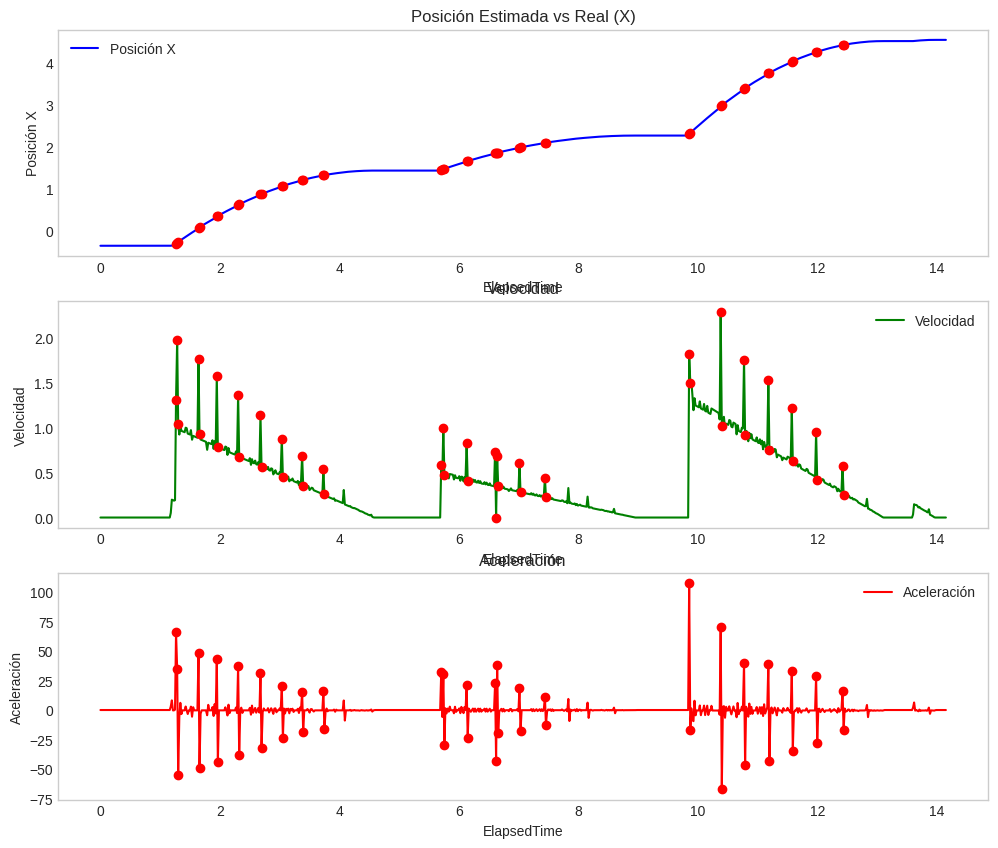

In [21]:
fig, axs = plot_data(time, pos_x, vel_x, acc_x)

abs_acc = np.abs(acc_x)
threshold = 10

alert_indices = np.where(abs_acc > threshold)[0]
axs[0].plot(time[alert_indices], pos_x[alert_indices], 'ro', label='Alertas de Aceleración')
axs[1].plot(time[alert_indices], vel_x[alert_indices], 'ro', label='Alertas de Aceleración')
axs[2].plot(time[alert_indices], acc_x[alert_indices], 'ro', label='Alertas de Aceleración')

plt.show()

In [25]:
alert_times = time[alert_indices]
delta_times = np.diff(alert_times)

min_delta_threshold = 0.1  # Umbral mínimo de tiempo entre alertas en segundos
max_delta_threshold = 1.0  # Umbral máximo de tiempo entre alertas en segundos

filtered_delta_times = delta_times[(delta_times >= min_delta_threshold) & (delta_times <= max_delta_threshold)]

print("Tiempos entre alertas de aceleración (en segundos):")
for dt in filtered_delta_times:
    print(f"{dt:.5f}, {dt*60:.5f} ticks")  # Convertir a ticks (1 tick = 1/60 segundos)

Tiempos entre alertas de aceleración (en segundos):
0.34000, 20.40000 ticks
0.28900, 17.34000 ticks
0.33900, 20.34000 ticks
0.35600, 21.36000 ticks
0.33900, 20.34000 ticks
0.32200, 19.32000 ticks
0.33800, 20.28000 ticks
0.37200, 22.32000 ticks
0.45800, 27.48000 ticks
0.35600, 21.36000 ticks
0.40800, 24.48000 ticks
0.50800, 30.48000 ticks
0.37200, 22.32000 ticks
0.38900, 23.34000 ticks
0.37400, 22.44000 ticks
0.39000, 23.40000 ticks
0.42300, 25.38000 ticks
